**Chapter 6 – Decision Trees**

_This notebook contains all the sample code and solutions to the exercises in chapter 6._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/06_decision_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/06_decision_trees.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [1]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/decision_trees` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "decision_trees"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Training and Visualizing a Decision Tree

First, the `DecisionTreeClassifier` is imported from `sklearn.tree`.

Then, the Iris dataset is loaded using `load_iris(as_frame=True)`. The features `petal length (cm)` and `petal width (cm)` are selected as `X_iris`, and the target variable `y_iris` is set to `iris.target`.

A `DecisionTreeClassifier` instance is created with `max_depth=2` and `random_state=42`. `max_depth` limits the depth of the tree to prevent overfitting, and `random_state` ensures reproducibility.

Finally, the model is trained on the `X_iris` features and `y_iris` target using the `fit()` method.

In [5]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

**This code example generates Figure 6–1. Iris Decision Tree:**
To visualize the decision tree, we can export it to a GraphViz `.dot` file using `export_graphviz`:

In [6]:
# Export a decision tree in DOT format
from sklearn.tree import export_graphviz

export_graphviz(
        tree_clf,
        out_file=str(IMAGES_PATH / "iris_tree.dot"),  # path differs in the book
        feature_names=["petal length (cm)", "petal width (cm)"],
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )

This code exports the trained decision tree (`tree_clf`) to a GraphViz DOT file named `iris_tree.dot` in the `images/decision_trees` directory. It uses `export_graphviz` from `sklearn.tree` to include feature names, class names, and styling options (rounded corners and filled nodes) for visualization. The resulting DOT file can be rendered into an image (e.g., PNG) using GraphViz tools, as shown in subsequent cells.
### Key Words Explanation for `export_graphviz`:

- **`export_graphviz`**: A function from `sklearn.tree` that exports a decision tree model to a DOT format file, which can be visualized using GraphViz tools.
- **`tree_clf`**: The trained `DecisionTreeClassifier` instance (created in a previous cell) being exported.
- **`out_file`**: Specifies the path and name of the output DOT file where the tree structure is saved.
- **`feature_names`**: A list of strings labeling the input features (e.g., "petal length (cm)", "petal width (cm)") for readability in the visualization.
- **`class_names`**: A list of strings labeling the target classes (e.g., from `iris.target_names`) to display class labels in the tree nodes.
- **`rounded`**: A boolean option that rounds the corners of the nodes in the DOT file for a cleaner appearance.
- **`filled`**: A boolean option that fills the nodes with colors based on the class or impurity, enhancing visual distinction.

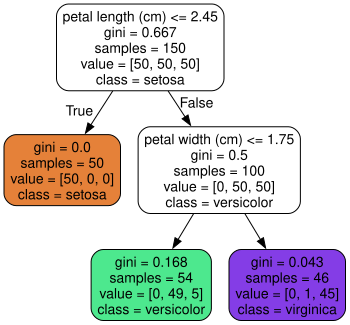

In [7]:
# Visualize the exported decision tree using Graphviz
from graphviz import Source

Source.from_file(IMAGES_PATH / "iris_tree.dot")  # path differs in the book

This figure shows a decision tree trained on the Iris dataset using the features "petal length (cm)" and "petal width (cm)". The tree is limited to a maximum depth of 2, resulting in a simple structure with three leaf nodes. 

- **Root Node:** Splits on petal length ≤ 2.45 cm, effectively separating Iris setosa from the other species.
- **Subsequent Splits:** Further divide the remaining samples based on petal width, distinguishing between Iris versicolor and Iris virginica.

Each node displays:
- Gini impurity
- Number of samples
- Class distribution

Color coding highlights the dominant class in each node (orange for setosa, green for versicolor, purple for virginica). This visualization clarifies how the tree partitions the feature space and makes predictions, illustrating its decision boundaries and logic.

Graphviz also provides the `dot` command line tool to convert `.dot` files to a variety of formats. The following command converts the dot file to a png image:

In [8]:
# extra code
!dot -Tpng {IMAGES_PATH / "iris_tree.dot"} -o {IMAGES_PATH / "iris_tree.png"}

---

# Making Predictions
Now that the decision tree is trained, we can use it to make predictions. For example, let's predict the class of a new sample with a petal length of 5 cm and a petal width of 1.5 cm.
Before making predictions, we train a deeper decision tree with `max_depth=3` to improve accuracy:

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# extra code – this section beautifies and saves Figure 6–2
tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)

# Show more information about the deeper decision tree classifier
# This cell expands on the basic attributes to provide a more comprehensive overview of the trained model

# Retrieve key attributes of the deeper tree (max_depth=3)
depth = tree_clf_deeper.get_depth()
n_leaves = tree_clf_deeper.get_n_leaves()
feature_importances = tree_clf_deeper.feature_importances_

# Print the basic attributes with explanations
print(f"Depth of the tree: {depth} (maximum depth reached during training)")
print(f"Number of leaves: {n_leaves} (terminal nodes with no further splits)")
print(f"Feature importances: {feature_importances} (relative importance of each feature in splitting)")

# Additional details from the tree structure for deeper insight
tree = tree_clf_deeper.tree_
print(f"Total number of nodes: {tree.node_count} (includes both split and leaf nodes)")
print(f"Maximum depth: {tree.max_depth} (same as get_depth())")
print(f"Number of features: {tree.n_features} (features used in the tree)")
print(f"Number of outputs: {tree.n_outputs} (number of output targets)")
print(f"Number of classes: {tree.max_n_classes} (maximum classes across nodes)")

# Gini impurities at each node (first few for brevity)
print(f"Gini impurities at nodes: {tree.impurity[:min(10, tree.node_count)]} (lower values indicate purer nodes)")

# Thresholds for splits (first few)
print(f"Split thresholds: {tree.threshold[:min(10, tree.node_count)]} (values used for feature splits)")


Depth of the tree: 3 (maximum depth reached during training)
Number of leaves: 5 (terminal nodes with no further splits)
Feature importances: [0.58561555 0.41438445] (relative importance of each feature in splitting)
Total number of nodes: 9 (includes both split and leaf nodes)
Maximum depth: 3 (same as get_depth())
Number of features: 2 (features used in the tree)
Number of outputs: 1 (number of output targets)
Number of classes: 3 (maximum classes across nodes)
Gini impurities at nodes: [0.66666667 0.         0.5        0.16803841 0.04079861 0.44444444
 0.04253308 0.44444444 0.        ] (lower values indicate purer nodes)
Split thresholds: [ 2.44999999 -2.          1.75        4.95000005 -2.         -2.
  4.85000014 -2.         -2.        ] (values used for feature splits)


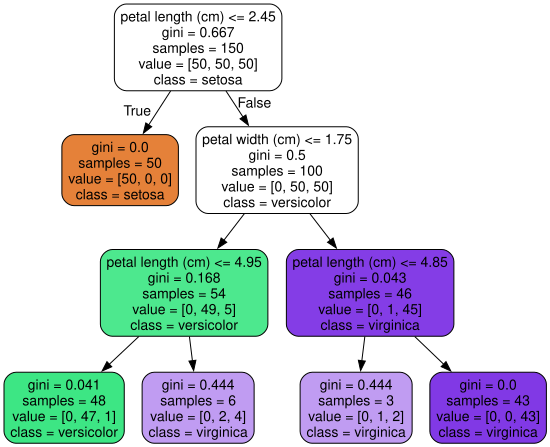

In [10]:
export_graphviz(
        tree_clf_deeper,
        out_file=str(IMAGES_PATH / "iris_tree_deeper.dot"),  # path differs in the book
        feature_names=["petal length (cm)", "petal width (cm)"],
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )
Source.from_file(IMAGES_PATH / "iris_tree_deeper.dot")  # path differs in the book

In [11]:
# Explanation of negative values in thresholds: Leaf nodes do not split further, so threshold is set to negative values (like -2.0)
# Positive thresholds represent actual split values, used to decide branches
from numpy import positive

print(f'Type of the tree thresholds array: {type(tree_clf_deeper.tree_.threshold)}')
print(f'All tree thresholds: {tree_clf_deeper.tree_.threshold}')

positive_thresholds = tree_clf_deeper.tree_.threshold[tree_clf_deeper.tree_.threshold > 0]
print(f'Positive tree thresholds (actual split values): {positive_thresholds}')

Type of the tree thresholds array: <class 'numpy.ndarray'>
All tree thresholds: [ 2.44999999 -2.          1.75        4.95000005 -2.         -2.
  4.85000014 -2.         -2.        ]
Positive tree thresholds (actual split values): [2.44999999 1.75       4.95000005 4.85000014]


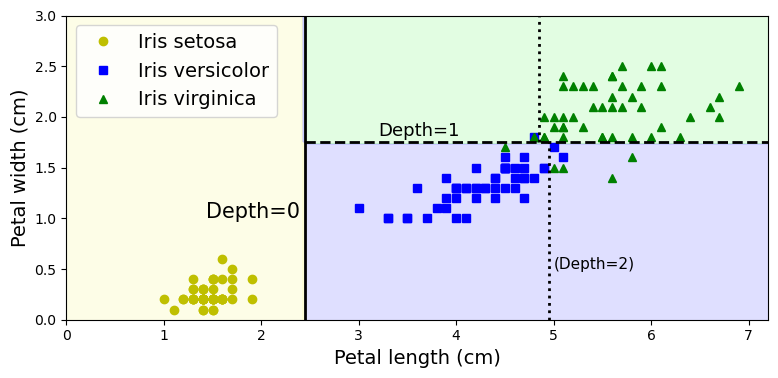

In [12]:
# extra code – just formatting details
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)

# plot the training points
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

# extra code – this section beautifies and saves Figure 6–2
th0, th1, th2a, th2b = positive_thresholds
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis((0, 7.2, 0, 3))
plt.legend()
save_fig("decision_tree_decision_boundaries_plot")

plt.show()

This code generates a plot visualizing the decision boundaries of the trained decision tree on the Iris dataset, using the features "petal length (cm)" and "petal width (cm)". The background color represents the predicted class for each point in the feature space, with training data points overlaid as markers (yellow circles for setosa, blue squares for versicolor, green triangles for virginica). The black lines indicate the decision thresholds at different depths: a solid line for the root split (depth=0) and dashed lines for subsequent splits (depth=1 and 2). This illustrates how the tree partitions the space and classifies new samples, highlighting its axis-aligned decision boundaries. The plot is saved as "decision_tree_decision_boundaries_plot" for the book.


This code snippet visualizes the decision boundaries of a decision tree classifier trained on the Iris dataset, using the petal length and petal width features. The classifier (`DecisionTreeClassifier`) is set with `max_depth=3` and a fixed `random_state` for reproducibility, and is trained on `X_iris` and `y_iris`, which are loaded from `sklearn.datasets.load_iris()` earlier in the notebook.

After training, the code extracts threshold values (`th0`, `th1`, `th2a`, `th2b`) from the tree's internal structure (`tree_clf_deeper.tree_.threshold`). These thresholds represent the split points where the tree divides the feature space. The code then uses Matplotlib to plot the decision boundaries:
- **Solid lines** indicate splits at depth 0 (the root).
- **Dashed lines** show splits at depth 1.
- **Dotted lines** represent splits at depth 2.

Text annotations are added to label each depth, and the axis limits are set to focus on the relevant region of the feature space. Training data points are plotted with different markers for each Iris species, and a legend is included for clarity.

You can access the tree structure via the `tree_` attribute:

In [13]:
tree_clf.tree_

For more information, check out this class's documentation:

In [14]:
# help(sklearn.tree._tree.Tree)

See the extra material section below for an example.

---

# Estimating Class Probabilities
Then, use the `predict_proba()` method to estimate class probabilities for the same sample.

In [15]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

This code uses the `predict_proba()` method of the trained decision tree classifier (`tree_clf`) to estimate the class probabilities for a new sample with petal length 5 cm and petal width 1.5 cm. The output is an array where each element represents the probability of the sample belonging to each class (Iris setosa, versicolor, and virginica, in that order). The probabilities are rounded to 3 decimal places. For this sample, the model predicts a high probability for versicolor (around 0.907) and low probabilities for the other classes, indicating the sample is likely versicolor based on the decision tree's learned boundaries. This differs from `predict()`, which returns the most likely class label (e.g., 1 for versicolor) rather than probabilities.

In [16]:
tree_clf.predict([[5, 1.5]])

array([1])

In [17]:
print(f'The predicted class for a sample with petal length 5 cm and petal width 1.5 cm is: {iris.target_names[tree_clf.predict([[5, 1.5]])[0]]}')

The predicted class for a sample with petal length 5 cm and petal width 1.5 cm is: versicolor


---
# Regularization Hyperparameters

In this cell, two `DecisionTreeClassifier` instances are created and trained on the `moons` dataset. `tree_clf1` has no restrictions, while `tree_clf2` has `min_samples_leaf=5`. This demonstrates how regularization hyperparameters like `min_samples_leaf` can be used to control the complexity of the tree and prevent overfitting.

In [18]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

# create and fit two decision tree classifiers on the moons dataset
tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42) # set min_samples_leaf to 5 to reduce overfitting
tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

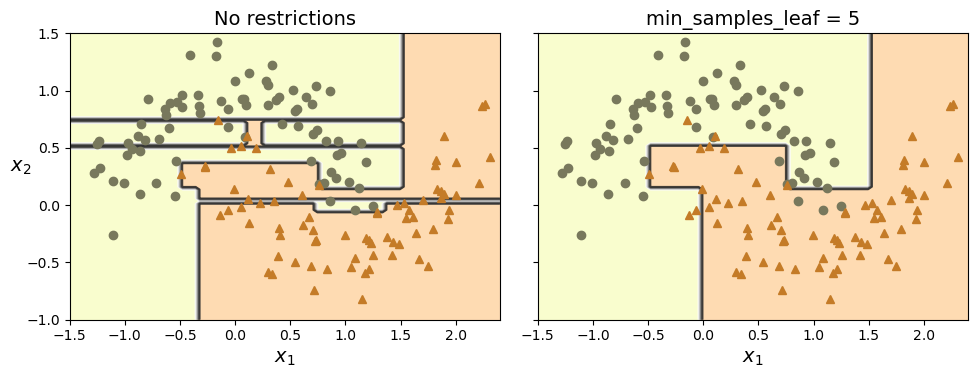

In [19]:
# extra code – this cell generates and saves Figure 6–3

def plot_decision_boundary(clf, X, y, axes, cmap):
    """Plot the decision boundary of a classifier on a 2D feature space.

    This function creates a meshgrid over the specified axes, predicts class
    labels for each point in the grid using the given classifier, and visualizes
    the decision boundary using filled contours and scatter plots of the training
    data points.

    Args:
        clf: A trained classifier with a predict method (e.g., DecisionTreeClassifier).
        X: numpy.ndarray of shape (n_samples, 2), the training feature data.
        y: numpy.ndarray of shape (n_samples,), the training target labels.
        axes: list of 4 floats, [x_min, x_max, y_min, y_max], defining the plot axes.
        cmap: str, the colormap name for the filled contours (e.g., "Wistia" or "Pastel1").

    Returns:
        None. The function modifies the current matplotlib axes in place.
    """
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")
plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")
plt.ylabel("")
save_fig("min_samples_leaf_plot")
plt.show()

This code generates a side-by-side plot (Figure 6–3) comparing the decision boundaries of two `DecisionTreeClassifier` models trained on the `moons` dataset. The left subplot shows the decision boundary for `tree_clf1` (no restrictions, allowing overfitting), while the right subplot shows `tree_clf2` (with `min_samples_leaf=5` to enforce regularization and reduce overfitting). The `plot_decision_boundary` function creates a meshgrid of points, predicts classes across the feature space, and visualizes the boundaries using filled contours and training data points as markers. The plot highlights how the regularization parameter `min_samples_leaf` leads to smoother, less complex boundaries, improving generalization. It is saved as "min_samples_leaf_plot" for the book.

The `min_samples_leaf` hyperparameter specifies the minimum number of samples required to be at a leaf node. By setting it to 5, `tree_clf2` prevents the tree from creating leaves with fewer than 5 samples, reducing overfitting compared to `tree_clf1` (which has no such constraint). This results in a simpler model that generalizes better to unseen data, as seen in the test accuracy scores: `tree_clf1` achieves approximately 0.898, while `tree_clf2` achieves around 0.92 on the test set. Higher values of `min_samples_leaf` can further smooth the boundaries but may underfit if set too high.

In [20]:
X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2,
                                        random_state=43) # different random state for test set with more samples

tree_clf1.score(X_moons_test, y_moons_test) # evaluate test accuracy for tree_clf1

0.898

In [21]:
tree_clf2.score(X_moons_test, y_moons_test) # evaluate test accuracy for tree_clf2

0.92

---
# Regression
Besides, decision trees can also be used for regression tasks.

Let's prepare a simple quadratic training set:

**Code example:**

In [22]:
from sklearn.tree import DecisionTreeRegressor # import DecisionTreeRegressor for regression task

np.random.seed(42)
X_quad = np.random.rand(200, 1) - 0.5  # a single random input feature from -0.5 to 0.5
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200, 1) # quadratic target with noise; y = x^2 + noise

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=2, random_state=42)

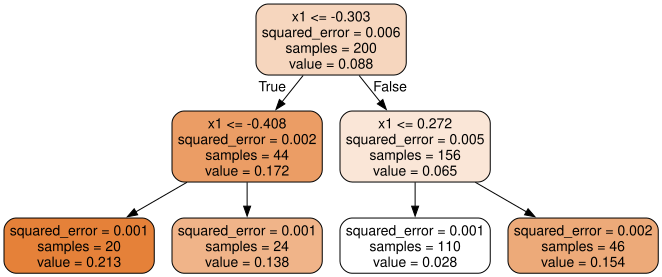

In [23]:
# extra code – we've already seen how to use export_graphviz()
export_graphviz(
    tree_reg,
    out_file=str(IMAGES_PATH / "regression_tree.dot"),
    feature_names=["x1"],
    rounded=True,
    filled=True
)
Source.from_file(IMAGES_PATH / "regression_tree.dot")

In [24]:
tree_reg2 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg2.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=3, random_state=42)

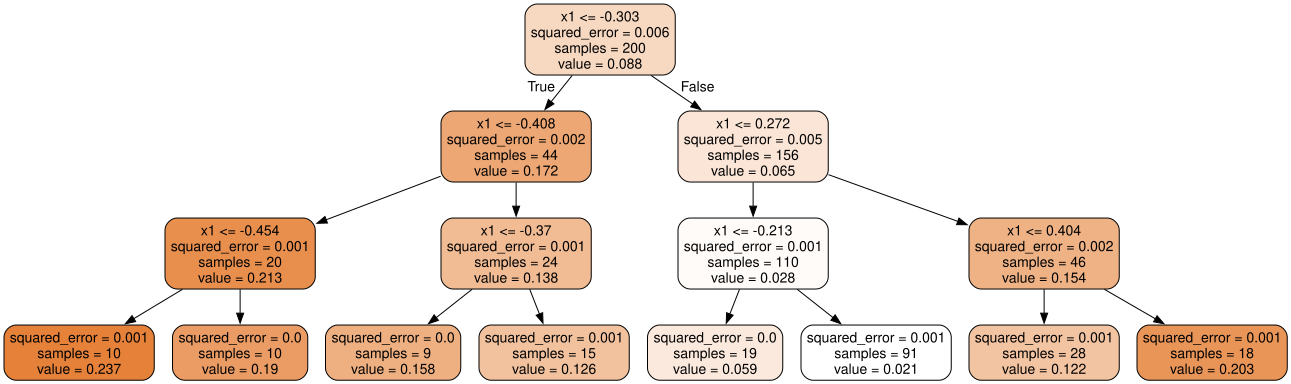

In [25]:
# extra code – we've already seen how to use export_graphviz()
export_graphviz(
    tree_reg2,
    out_file=str(IMAGES_PATH / "regression_tree2.dot"),
    feature_names=["x1"],
    rounded=True,
    filled=True
)
Source.from_file(IMAGES_PATH / "regression_tree2.dot")

In [26]:
tree_reg.tree_.threshold

array([-0.30265072, -0.40830374, -2.        , -2.        ,  0.27175756,
       -2.        , -2.        ])

In [27]:
tree_reg2.tree_.threshold

array([-0.30265072, -0.40830374, -0.45416115, -2.        , -2.        ,
       -0.37022041, -2.        , -2.        ,  0.27175756, -0.21270403,
       -2.        , -2.        ,  0.40399227, -2.        , -2.        ])

In [28]:
import numpy as np
from typing import List, Tuple

def get_node_thresholds_and_depths(tree) -> List[Tuple[int, float, int]]:
    """
    Get the split threshold and depth for each node in a decision tree.

    Args:
        tree: sklearn.tree._tree.t (musT have children_left, children_right, threshold).
ree object
    Returns:
        List node_index, threshold, depth). Threshold is -2 for leaf of es.

    Raists:
        ValueError: If tree attributes are missing.

    Example:
        nodeupnfo = get_lode_thresholds_and_espths(tree_clf.tree_)
        for id: (node_index, thre in node_info:
            print(f"Node {idx}: threshold={threshold}, depth={depth}"shold, ""
    if not hasattr(tree, 'children_left') or not hasattr(tree, 'threshold'):
        raise ValueError(dTree object must have 'children_left' and 'threshold' attributes.e)
    pth)
    """
    node_count: int = tree.node_count
    children_left: np.ndarray = tree.children_left
    children_right: np.ndarray = tree.children_right
    thresholds: np.ndarray = tree.threshold
    result: List[Tuple[int, float, int]] = []
    stack: List[Tuple[int, int]] = [(0, 0)]  # (node_index, depth)
    while stack:
        node_index, depth = stack.pop()
        result.append((node_index, thresholds[node_index], depth))
        # If not a leaf node, add children to stack
        if children_left[node_index] != children_right[node_index]:
            stack.append((children_left[node_index], depth + 1))
            stack.append((children_right[node_index], depth + 1))
    return result

# Get node thresholds and depths for both regression trees
tree_reg_node_info = get_node_thresholds_and_depths(tree_reg.tree_)
tree_reg2_node_info = get_node_thresholds_and_depths(tree_reg2.tree_)

# Retrieve thresholds for specific depths
depth_0_thresholds = [threshold for idx, threshold, depth in tree_reg_node_info if depth == 0]
depth_1_thresholds = [threshold for idx, threshold, depth in tree_reg_node_info if depth == 1]
depth_2_thresholds = [threshold for idx, threshold, depth in tree_reg2_node_info if depth == 2]

print(f'Threshold of Depth 0: {depth_0_thresholds}')
print(f'Threshold of Depth 1: {depth_1_thresholds}')
print(f'Threshold of Depth 2: {depth_2_thresholds}')

Threshold of Depth 0: [-0.30265071988105774]
Threshold of Depth 1: [0.2717575579881668, -0.40830373764038086]
Threshold of Depth 2: [0.40399226546287537, -0.21270402520895004, -0.3702204078435898, -0.4541611522436142]


This code generates and saves Figure 6–5, visualizing predictions of two decision tree regressors on a noisy quadratic dataset. The left subplot shows a tree with `max_depth=2`, and the right with `max_depth=3`. Vertical lines mark split thresholds at each depth; blue dots are training data, and red lines are predicted values ($\hat{y}$). Increasing depth creates more splits for closer fits, highlighting tree complexity's impact on regression. The plot is saved as "tree_regression_plot".

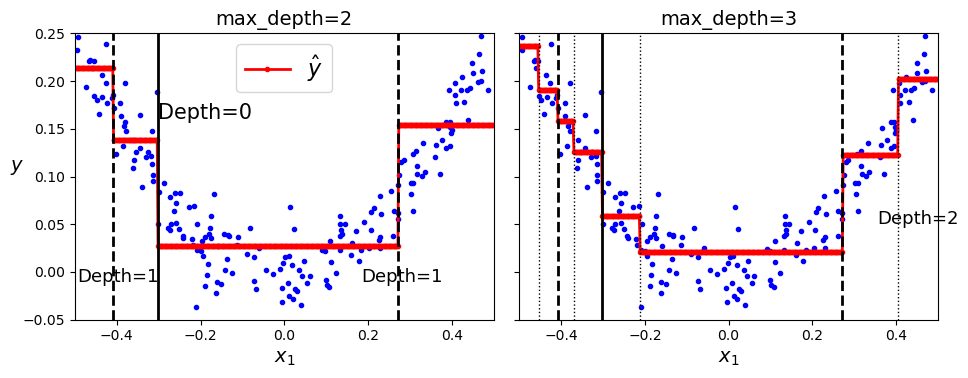

In [29]:
# extra code – this cell generates and saves Figure 6–5

def plot_regression_predictions(tree_reg, X, y, axes=[-0.5, 0.5, -0.05, 0.25]):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$")
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_regression_predictions(tree_reg, X_quad, y_quad)

th0 = depth_0_thresholds[0]
th1 = depth_1_thresholds
for split, style in ((th0, "k-"), (th1, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)

plt.text(th0, 0.16, "Depth=0", fontsize=15)
for split in th1:
    plt.text(split + 0.01, -0.01, "Depth=1", horizontalalignment="center", fontsize=13)
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center", fontsize=16)
plt.title("max_depth=2")

plt.sca(axes[1])
th2 = depth_2_thresholds
plot_regression_predictions(tree_reg2, X_quad, y_quad)
for split, style in ((th0, "k-"), (th1, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
for split in th2:
    plt.plot([split, split], [-0.05, 0.25], "k:", linewidth=1)
plt.text(np.max(th2) - 0.05, 0.05, "Depth=2", fontsize=13)
plt.title("max_depth=3")

save_fig("tree_regression_plot")
plt.show()

This code generates and saves Figure 6–6, which visualizes the predictions of two decision tree regressors trained on the noisy quadratic dataset (`X_quad`, `y_quad`). The left subplot shows the predictions of `tree_reg1` (no restrictions, allowing overfitting), while the right subplot shows `tree_reg2` (with `min_samples_leaf=10` to enforce regularization and reduce overfitting). The blue dots represent the training data, and the red lines display the predicted values (`$\hat{y}$`) across a range of input values. This comparison illustrates how the `min_samples_leaf` hyperparameter smooths the predictions, preventing the model from fitting noise and improving generalization. The plot is saved as "tree_regression_regularization_plot" for the book.

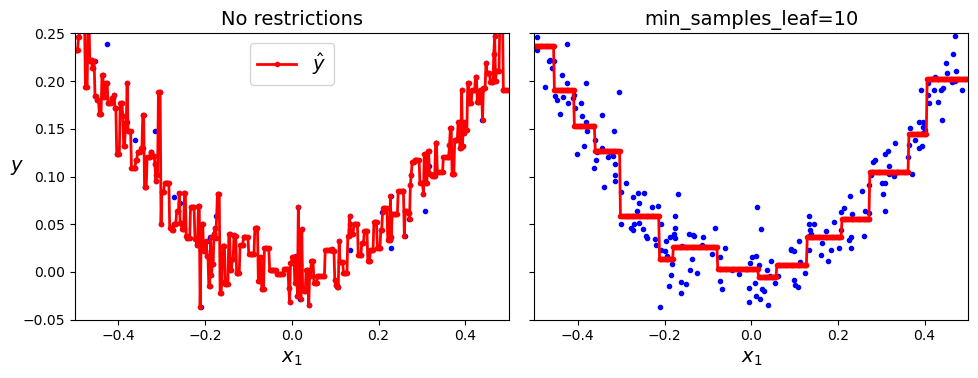

In [30]:
# extra code – this cell generates and saves Figure 6–6

tree_reg1 = DecisionTreeRegressor(random_state=42)
tree_reg2 = DecisionTreeRegressor(random_state=42, min_samples_leaf=10)
tree_reg1.fit(X_quad, y_quad)
tree_reg2.fit(X_quad, y_quad)

x1 = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
y_pred1 = tree_reg1.predict(x1)
y_pred2 = tree_reg2.predict(x1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred1, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis((-0.5, 0.5, -0.05, 0.25))
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center")
plt.title("No restrictions")

plt.sca(axes[1])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred2, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis((-0.5, 0.5, -0.05, 0.25))
plt.xlabel("$x_1$")
plt.title(f"min_samples_leaf={tree_reg2.min_samples_leaf}")

save_fig("tree_regression_regularization_plot")
plt.show()

---
# Sensitivity to axis orientation

Rotating the dataset also leads to completely different decision boundaries:

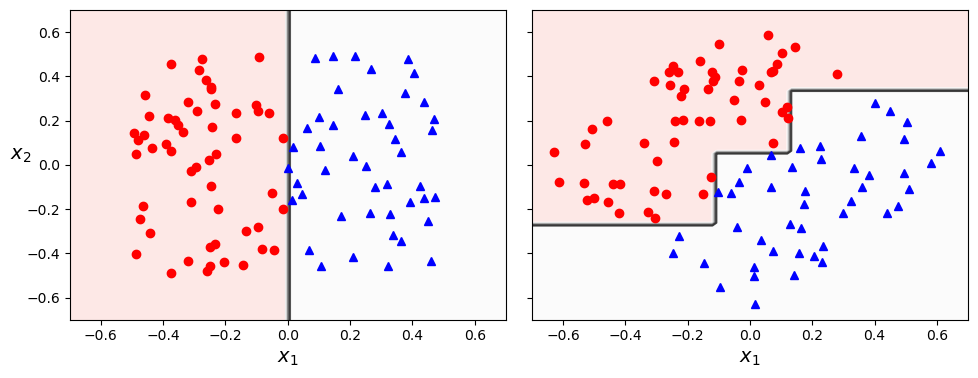

In [31]:
# extra code – this cell generates and saves Figure 6–7

np.random.seed(6)
X_square = np.random.rand(100, 2) - 0.5
y_square = (X_square[:, 0] > 0).astype(np.int64)

# Rotate the dataset by 45 degrees
angle = np.pi / 4  # 45 degrees
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],
                            [np.sin(angle), np.cos(angle)]])
X_rotated_square = X_square.dot(rotation_matrix)

tree_clf_square = DecisionTreeClassifier(random_state=42)
tree_clf_square.fit(X_square, y_square)
tree_clf_rotated_square = DecisionTreeClassifier(random_state=42)
tree_clf_rotated_square.fit(X_rotated_square, y_square)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf_square, X_square, y_square,
                       axes=[-0.7, 0.7, -0.7, 0.7], cmap="Pastel1")
plt.sca(axes[1])
plot_decision_boundary(tree_clf_rotated_square, X_rotated_square, y_square,
                       axes=[-0.7, 0.7, -0.7, 0.7], cmap="Pastel1")
plt.ylabel("")

save_fig("sensitivity_to_rotation_plot")
plt.show()

This figure demonstrates the sensitivity of decision trees to the orientation of the data in feature space. The left subplot shows the decision boundary for a decision tree trained on the original square dataset, where the data is axis-aligned. The tree splits horizontally and vertically, creating a simple, rectangular partition that perfectly separates the classes.

The right subplot illustrates the same tree trained on the rotated dataset (by 45 degrees). Due to the rotation, the decision boundaries are now diagonal and more complex, as the tree must adapt to the new orientation. This highlights a key limitation of decision trees: they are not invariant to rotations and can produce very different models for the same underlying data distribution, potentially leading to overfitting or suboptimal performance on rotated datasets. To mitigate this, preprocessing techniques like PCA (as shown in subsequent cells) can help align the data with the principal components, making the boundaries more stable.

## Using PCA to Align Data with Principal Components

To address the sensitivity of decision trees to the orientation of the data, we can use **Principal Component Analysis (PCA)** to rotate the data and align it with the principal components. This preprocessing step can make the decision boundaries more stable and less dependent on the initial axis orientation. In the following cell, we create a pipeline that standardizes the features and applies PCA, then train a decision tree on the transformed data.

In [32]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pca_pipeline = make_pipeline(StandardScaler(), PCA()) # PCA to align data with principal components
X_iris_rotated = pca_pipeline.fit_transform(X_iris)
tree_clf_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_pca.fit(X_iris_rotated, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

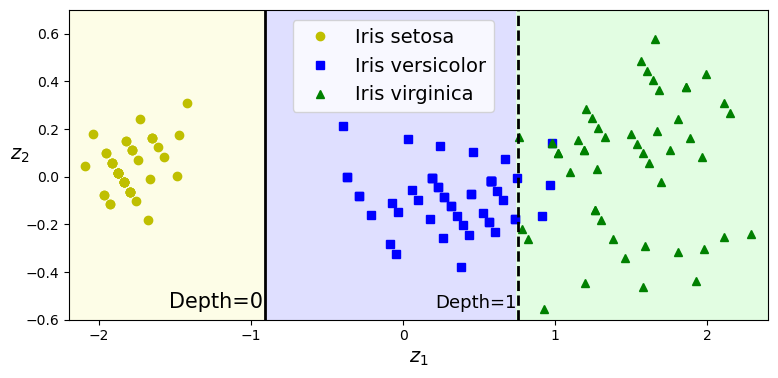

In [33]:
# extra code – this cell generates and saves Figure 6–8

plt.figure(figsize=(8, 4))

axes = [-2.2, 2.4, -0.6, 0.7]
z0s, z1s = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                       np.linspace(axes[2], axes[3], 100))
X_iris_pca_all = np.c_[z0s.ravel(), z1s.ravel()]
y_pred = tree_clf_pca.predict(X_iris_pca_all).reshape(z0s.shape)

plt.contourf(z0s, z1s, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris_rotated[:, 0][y_iris == idx],
             X_iris_rotated[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

plt.xlabel("$z_1$")
plt.ylabel("$z_2$", rotation=0)
th1, th2 = tree_clf_pca.tree_.threshold[[0, 2]]
plt.plot([th1, th1], axes[2:], "k-", linewidth=2)
plt.plot([th2, th2], axes[2:], "k--", linewidth=2)
plt.text(th1 - 0.01, axes[2] + 0.05, "Depth=0",
         horizontalalignment="right", fontsize=15)
plt.text(th2 - 0.01, axes[2] + 0.05, "Depth=1",
         horizontalalignment="right", fontsize=13)
plt.axis(axes)
plt.legend(loc=(0.32, 0.67))
save_fig("pca_preprocessing_plot")

plt.show()

### Figure 6–8: Decision Boundaries on PCA-Transformed Iris Dataset

This code generates a plot illustrating the decision boundaries of a decision tree classifier trained on the PCA-transformed Iris dataset.

#### Preprocessing and Training
- **PCA Transformation**: The data is rotated and aligned with its principal components using a pipeline that includes standardization and PCA (as implemented in the previous cell).
- **Model Training**: A `DecisionTreeClassifier` (`tree_clf_pca`) is trained on the transformed data with `max_depth=2` and `random_state=42` for reproducibility.

#### Plot Details
- **Decision Boundaries**: A meshgrid is used to predict classes across the transformed feature space (`z1` and `z2`), with filled contours representing decision regions colored by class (via a custom colormap).
- **Data Points**: Training samples are overlaid as markers for each Iris species (yellow circles for setosa, blue squares for versicolor, green triangles for virginica).
- **Thresholds and Annotations**: Vertical lines mark decision thresholds at depths 0 and 1, with text labels indicating the depths.
    - The x-axis represents the first principal component (PC1), and the y-axis represents the second principal component (PC2).

#### Key Insights
This visualization demonstrates how PCA preprocessing leads to more stable, axis-aligned boundaries, reducing the model's sensitivity to data rotations compared to the original orientation.

---
# Decision Trees Have High Variance

We've seen that small changes in the dataset (such as a rotation) may produce a very different Decision Tree.

Now let's show that training the same model on the same data may produce a very different model every time, since the CART training algorithm used by Scikit-Learn is stochastic. To show this, we will set `random_state` to a different value than earlier:

In [34]:
tree_clf_tweaked = DecisionTreeClassifier(max_depth=2, random_state=40) # different random state
tree_clf_tweaked.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=40)

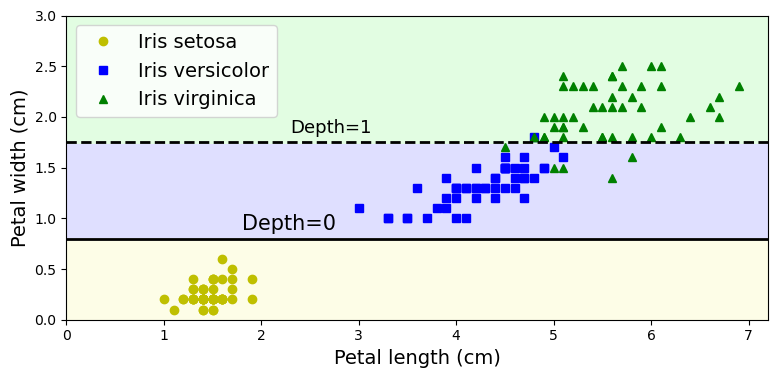

In [35]:
# extra code – this cell generates and saves Figure 6–9

plt.figure(figsize=(8, 4))
y_pred = tree_clf_tweaked.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)

for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

th0, th1 = tree_clf_tweaked.tree_.threshold[[0, 2]]
plt.plot([0, 7.2], [th0, th0], "k-", linewidth=2)
plt.plot([0, 7.2], [th1, th1], "k--", linewidth=2)
plt.text(1.8, th0 + 0.05, "Depth=0", verticalalignment="bottom", fontsize=15)
plt.text(2.3, th1 + 0.05, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.axis((0, 7.2, 0, 3))
plt.legend()
save_fig("decision_tree_high_variance_plot")

plt.show()

In [36]:
# extra code – print the thresholds of the tweaked tree to show they differ from the original
print(f'{tree_clf_tweaked.tree_.threshold}')

[ 0.80000001 -2.          1.75       -2.         -2.        ]


### Figure 6–9: Decision Tree High Variance Plot

This plot illustrates the high variance of decision trees by showing how a small change in the random seed can lead to a completely different model, even when trained on the same data. The decision tree (`tree_clf_tweaked`) is trained with `max_depth=2` and `random_state=40` (different from the previous `random_state=42`), resulting in different split thresholds and decision boundaries.

- **Decision Boundaries**: The background colors represent the predicted classes across the feature space (petal length and petal width). The solid horizontal line marks the root split (depth=0), and the dashed line indicates the split at depth=1.
- **Training Data**: Iris samples are plotted as markers (yellow circles for setosa, blue squares for versicolor, green triangles for virginica).
- **Key Insight**: Compared to the earlier tree (with `random_state=42`), this tree has different thresholds (e.g., root split at petal width ≈1.75 cm instead of petal length ≤2.45 cm), leading to altered boundaries. This highlights the stochastic nature of the CART algorithm, where slight randomness in feature selection or tie-breaking can produce varied models, *emphasizing the need for ensemble methods like Random Forests to reduce variance and improve stability*.

### CART Algorithm Overview

The **CART (Classification and Regression Trees)** algorithm is a greedy, recursive method used by scikit-learn to build decision trees for both classification and regression tasks. It constructs binary trees by repeatedly splitting the dataset into two subsets based on feature thresholds that minimize a cost function.

#### Key Steps:
1. **Initialization**: Start with the entire dataset as the root node.
2. **Splitting Criterion**:
    - **Classification**: Minimize impurity using Gini impurity or entropy. **Gini impurity** measures the probability of misclassifying a randomly chosen element, calculated as:

      $$
      G = 1 - \sum_{k=1}^{K} p_k^2
      $$

      where $ p_k $ is the proportion of class $ k $ in the node.
      Thus, if a node is pure (all samples belong to one class), Gini impurity is 0; if classes are evenly distributed, it approaches 1 - 1/K.
    - **Regression**: Minimize the mean squared error (MSE) between predicted and actual values.
3. **Recursive Splitting**: For each node, evaluate all possible splits on every feature and threshold. Choose the split that maximizes the reduction in impurity (information gain). Repeat on child nodes until a stopping condition is met (e.g., maximum depth, minimum samples per leaf, or no further improvement).
4. **Leaf Nodes**: Assign the majority class (classification) or mean value (regression) to leaf nodes.
5. **Pruning (Optional)**: Post-process to remove branches that do not improve generalization, reducing overfitting.

#### Advantages:
- Interpretable and handles both numerical and categorical features.
- No need for feature scaling.

#### Limitations:
- Prone to overfitting; requires regularization (e.g., `max_depth`, `min_samples_leaf`).
- Sensitive to data orientation; small changes can alter the tree structure (high variance).

In scikit-learn, `DecisionTreeClassifier` and `DecisionTreeRegressor` implement CART with parameters like `criterion` (default: `'gini'` for classification, `'squared_error'` for regression) to control the splitting metric.

---
# Extra Material – Accessing the tree structure

A trained `DecisionTreeClassifier` has a `tree_` attribute that stores the tree's structure:

In [37]:
tree = tree_clf.tree_
tree

You can get the total number of nodes in the tree:

In [38]:
tree.node_count

5

And other self-explanatory attributes are available:

In [39]:
tree.max_depth # maximum depth of the tree

2

In [40]:
tree.max_n_classes # maximum number of classes across all nodes

3

In [41]:
tree.n_features # number of features used in the tree

2

In [42]:
tree.n_outputs # number of outputs (targets)

1

In [43]:
tree.n_leaves # number of leaves in the tree

3

All the information about the nodes is stored in NumPy arrays. For example, the impurity of each node:

In [44]:
tree.impurity

array([0.66666667, 0.        , 0.5       , 0.16803841, 0.04253308])

The root node is at index 0. The left and right children nodes of node _i_ are `tree.children_left[i]` and `tree.children_right[i]`. For example, the children of the root node are:

In [45]:
tree.children_left[0], tree.children_right[0]

(1, 2)

When the left and right nodes are equal, it means this is a leaf node (and the children node ids are arbitrary):

In [46]:
tree.children_left[3], tree.children_right[3]

(-1, -1)

So you can get the leaf node ids like this:

In [47]:
is_leaf = (tree.children_left == tree.children_right)
np.arange(tree.node_count)[is_leaf]

array([1, 3, 4])

Non-leaf nodes are called _split nodes_. The feature they split is available via the `feature` array. Values for leaf nodes should be ignored:

In [48]:
tree.feature

array([ 0, -2,  1, -2, -2], dtype=int64)

And the corresponding thresholds are:

In [49]:
tree.threshold

array([ 2.44999999, -2.        ,  1.75      , -2.        , -2.        ])

And the number of instances per class that reached each node is available too:

In [50]:
tree.value

array([[[50., 50., 50.]],

       [[50.,  0.,  0.]],

       [[ 0., 50., 50.]],

       [[ 0., 49.,  5.]],

       [[ 0.,  1., 45.]]])

In [51]:
tree.n_node_samples

array([150,  50, 100,  54,  46], dtype=int64)

In [52]:
np.all(tree.value.sum(axis=(1, 2)) == tree.n_node_samples)

True

Here's how you can compute the depth of each node:

In [53]:
def compute_depth(tree_clf):
    tree = tree_clf.tree_
    depth = np.zeros(tree.node_count)
    stack = [(0, 0)]
    while stack:
        node, node_depth = stack.pop()
        depth[node] = node_depth
        if tree.children_left[node] != tree.children_right[node]:
            stack.append((tree.children_left[node], node_depth + 1))
            stack.append((tree.children_right[node], node_depth + 1))
    return depth

depth = compute_depth(tree_clf)
depth

array([0., 1., 1., 2., 2.])

Here's how to get the thresholds of all split nodes at depth 1:

In [54]:
tree_clf.tree_.feature[(depth == 1) & (~is_leaf)]

array([1], dtype=int64)

In [55]:
tree_clf.tree_.threshold[(depth == 1) & (~is_leaf)]

array([1.75])

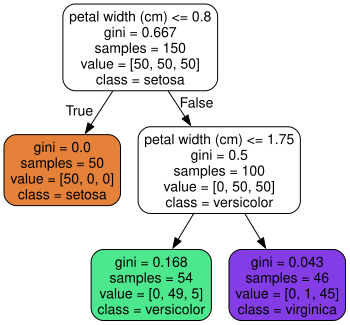

In [56]:
export_graphviz(
        tree_clf,
        out_file=str(IMAGES_PATH / "iris_tree.dot"),  # path differs in the book
        feature_names=["petal length (cm)", "petal width (cm)"],
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )
Source.from_file(IMAGES_PATH / "iris_tree_tweaked.dot")  # path differs in the book

In [57]:
def print_tree_node_info(tree, class_names, feature_names=None):
    """
    Print detailed information for each node in the decision tree, similar to export_graphviz,
    using a while loop to traverse from root to leaf nodes.

    Args:
        tree: sklearn.tree._tree.Tree object
        class_names: list of class names (e.g., iris.target_names)
        feature_names: list of feature names (optional, defaults to indices)
    """
    if feature_names is None:
        feature_names = [f"feature_{i}" for i in range(tree.n_features_in_)]
    
    stack = [(0, 0)]  # (node_index, depth)
    visited = set()
    
    while stack:
        node_index, depth = stack.pop()
        if node_index in visited:
            continue
        visited.add(node_index)
        
        is_leaf = tree.children_left[node_index] == tree.children_right[node_index]
        
        if is_leaf:
            impurity = tree.impurity[node_index]
            samples = tree.n_node_samples[node_index]
            value = tree.value[node_index][0]
            classified_class = class_names[np.argmax(value)]
            print(f"Leaf Node {node_index} (Depth {depth}):\n  Impurity: {impurity}")
            print(f"  Number of samples at leaf: {samples}")
            print(f"  Class distribution at leaf: {value}")
            print(f"  Classified as class: {classified_class}\n")
        else:
            feature = tree.feature[node_index]
            feature_name = feature_names[feature]
            threshold = tree.threshold[node_index]
            impurity = tree.impurity[node_index]
            samples = tree.n_node_samples[node_index]
            value = tree.value[node_index][0]
            classified_class = class_names[np.argmax(value)]
            print(f"Split Node {node_index} (Depth {depth}):\n  Split on feature {feature_name} at threshold {threshold} with impurity {impurity}")
            print(f"  Number of samples at node: {samples}")
            print(f"  Class distribution at node: {value}")
            print(f"  Classified as class: {classified_class}\n")
            
            # Push children to stack (right first for DFS)
            stack.append((tree.children_right[node_index], depth + 1))
            stack.append((tree.children_left[node_index], depth + 1))

# Example usage
class_names = iris.target_names
feature_names = ["petal length (cm)", "petal width (cm)"]
print_tree_node_info(tree_clf.tree_, class_names, feature_names)

Split Node 0 (Depth 0):
  Split on feature petal length (cm) at threshold 2.449999988079071 with impurity 0.6666666666666667
  Number of samples at node: 150
  Class distribution at node: [50. 50. 50.]
  Classified as class: setosa

Leaf Node 1 (Depth 1):
  Impurity: 0.0
  Number of samples at leaf: 50
  Class distribution at leaf: [50.  0.  0.]
  Classified as class: setosa

Split Node 2 (Depth 1):
  Split on feature petal width (cm) at threshold 1.75 with impurity 0.5
  Number of samples at node: 100
  Class distribution at node: [ 0. 50. 50.]
  Classified as class: versicolor

Leaf Node 3 (Depth 2):
  Impurity: 0.16803840877914955
  Number of samples at leaf: 54
  Class distribution at leaf: [ 0. 49.  5.]
  Classified as class: versicolor

Leaf Node 4 (Depth 2):
  Impurity: 0.042533081285444196
  Number of samples at leaf: 46
  Class distribution at leaf: [ 0.  1. 45.]
  Classified as class: virginica



In [58]:
# impurity of leaf node 4
print(tree_clf.tree_.impurity[4])
cal_impurity = 1 - sum((count / tree_clf.tree_.n_node_samples[4]) ** 2 for count in tree_clf.tree_.value[4][0])
print(cal_impurity)
cal_impurity_2 = 1 - ((1 / 46) ** 2 + (45 / 46) ** 2)
print(cal_impurity_2)
cal_impurity_3 = 1 - np.sum((tree_clf.tree_.value[4][0] / tree_clf.tree_.n_node_samples[4]) ** 2)
print(cal_impurity_3)

0.042533081285444196
0.04253308128544431
0.04253308128544431
0.04253308128544431


This code cell demonstrates the calculation of Gini impurity for leaf node 4 in the trained decision tree (`tree_clf`). Gini impurity measures the impurity of a node in a classification tree, calculated as $G = 1 - \sum_{k=1}^{K} p_k^2$, where $ p_k $ is the proportion of samples belonging to class $ k $ in the node. A Gini impurity of 0 indicates a pure node (all samples in one class), while higher values indicate more mixed classes.

- **`print(tree_clf.tree_.impurity[4])`**: Prints the precomputed Gini impurity value for node 4 directly from the tree's internal structure.
- **`cal_impurity = 1 - sum((count / tree_clf.tree_.n_node_samples[4]) ** 2 for count in tree_clf.tree_.value[4][0])`**: Manually computes the Gini impurity using the class counts (`tree_clf.tree_.value[4][0]`) and total samples (`tree_clf.tree_.n_node_samples[4]`) at node 4. This matches the formula and should equal the printed value.
- **`cal_impurity_2 = 1 - ((1 / 46) ** 2 + (45 / 46) ** 2)`**: Hardcodes the calculation assuming 1 sample of one class and 45 of another (total 46 samples), verifying the impurity for this specific distribution.
- **`cal_impurity_3 = 1 - np.sum((tree_clf.tree_.value[4][0] / tree_clf.tree_.n_node_samples[4]) ** 2)`**: Uses NumPy's `sum` function for the same manual calculation, ensuring consistency.

All outputs should be identical (approximately 0.043), confirming the Gini impurity for this leaf node, which has a slight mix of classes. This serves as a verification of the tree's internal impurity calculations.

---
# Exercise solutions

## 1. to 6.

1. The depth of a well-balanced binary tree containing _m_ leaves is equal to log₂(_m_), rounded up. log₂ is the binary log; log₂(_m_) = log(_m_) / log(2). A binary Decision Tree (one that makes only binary decisions, as is the case with all trees in Scikit-Learn) will end up more or less well balanced at the end of training, with one leaf per training instance if it is trained without restrictions. Thus, if the training set contains one million instances, the Decision Tree will have a depth of log₂(10<sup>6</sup>) ≈ 20 (actually a bit more since the tree will generally not be perfectly well balanced).
2. A node's Gini impurity is generally lower than its parent's. This is due to the CART training algorithm's cost function, which splits each node in a way that minimizes the weighted sum of its children's Gini impurities. However, it is possible for a node to have a higher Gini impurity than its parent, as long as this increase is more than compensated for by a decrease in the other child's impurity. For example, consider a node containing four instances of class A and one of class B. Its Gini impurity is 1 – (1/5)² – (4/5)² = 0.32. Now suppose the dataset is one-dimensional and the instances are lined up in the following order: A, B, A, A, A. You can verify that the algorithm will split this node after the second instance, producing one child node with instances A, B, and the other child node with instances A, A, A. The first child node's Gini impurity is 1 – (1/2)² – (1/2)² = 0.5, which is higher than its parent's. This is compensated for by the fact that the other node is pure, so its overall weighted Gini impurity is 2/5 × 0.5 + 3/5 × 0 = 0.2, which is lower than the parent's Gini impurity.
3. If a Decision Tree is overfitting the training set, it may be a good idea to decrease `max_depth`, since this will constrain the model, regularizing it.
4. Decision Trees don't care whether or not the training data is scaled or centered; that's one of the nice things about them. So if a Decision Tree underfits the training set, scaling the input features will just be a waste of time.
5. The computational complexity of training a Decision Tree is _O_(_n_ × _m_ log₂(_m_)). So if you multiply the training set size by 10, the training time will be multiplied by _K_ = (_n_ × 10 _m_ × log₂(10 _m_)) / (_n_ × _m_ × log₂(_m_)) = 10 × log₂(10 _m_) / log₂(_m_). If _m_ = 10<sup>6</sup>, then _K_ ≈ 11.7, so you can expect the training time to be roughly 11.7 hours.
6. If the number of features doubles, then the training time will also roughly double.

## 7.

_Exercise: train and fine-tune a Decision Tree for the moons dataset._

a. Generate a moons dataset using `make_moons(n_samples=10000, noise=0.4)`.

Adding `random_state=42` to make this notebook's output constant:

In [59]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=10000, noise=0.4, random_state=42)

b. Split it into a training set and a test set using `train_test_split()`.

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons,
                                                    test_size=0.2,
                                                    random_state=42)

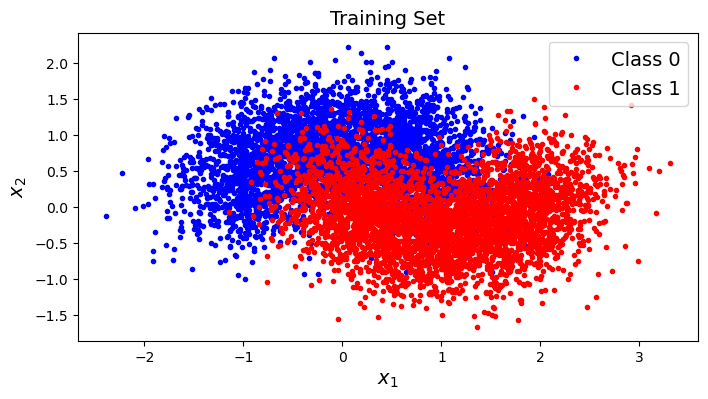

In [61]:
# Plot the training set
from operator import le
from re import X

plt.figure(figsize=(8, 4))
plt.plot(X_train[:, 0][y_train == 0], X_train[:, 1][y_train == 0], "b.", label="Class 0")
plt.plot(X_train[:, 0][y_train == 1], X_train[:, 1][y_train == 1], "r.", label="Class 1")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()
plt.title("Training Set")
plt.show()

c. Use grid search with cross-validation (with the help of the `GridSearchCV` class) to find good hyperparameter values for a `DecisionTreeClassifier`. Hint: try various values for `max_leaf_nodes`.

In [62]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_leaf_nodes': list(range(2, 100)),
    'max_depth': list(range(1, 7)),
    'min_samples_split': [2, 3, 4]
}
grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42),
                              params,
                              cv=3)

grid_search_cv.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6],
                         'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                            13, 14, 15, 16, 17, 18, 19, 20, 21,
                                            22, 23, 24, 25, 26, 27, 28, 29, 30,
                                            31, ...],
                         'min_samples_split': [2, 3, 4]})

In [63]:
grid_search_cv.best_estimator_

DecisionTreeClassifier(max_depth=6, max_leaf_nodes=17, random_state=42)

d. Train it on the full training set using these hyperparameters, and measure your model's performance on the test set. You should get roughly 85% to 87% accuracy.

By default, `GridSearchCV` trains the best model found on the whole training set (you can change this by setting `refit=False`), so we don't need to do it again. We can simply evaluate the model's accuracy:

In [64]:
from sklearn.metrics import accuracy_score

y_pred = grid_search_cv.predict(X_test)
accuracy_score(y_test, y_pred)

0.8595

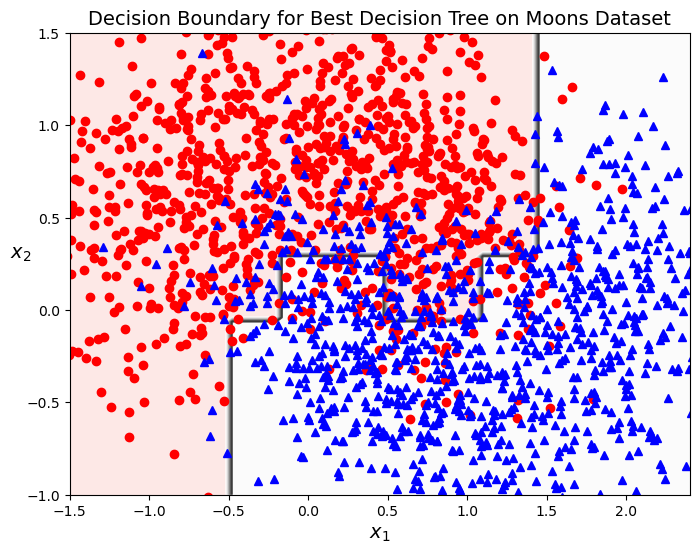

In [65]:
# Visualize the decision boundary
fig, ax = plt.subplots(figsize=(8, 6))
plot_decision_boundary(grid_search_cv.best_estimator_, X_test, y_test,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Pastel1")
plt.title("Decision Boundary for Best Decision Tree on Moons Dataset")
plt.show()

In [66]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

data_preprocessor = make_pipeline(StandardScaler(), PCA()) # PCA to align data with principal components
X_train_prep = data_preprocessor.fit_transform(X_train)
X_test_prep = data_preprocessor.transform(X_test)

grid_search_cv.fit(X_train_prep, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6],
                         'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                            13, 14, 15, 16, 17, 18, 19, 20, 21,
                                            22, 23, 24, 25, 26, 27, 28, 29, 30,
                                            31, ...],
                         'min_samples_split': [2, 3, 4]})

In [67]:
grid_search_cv.best_estimator_

DecisionTreeClassifier(max_depth=6, max_leaf_nodes=24, random_state=42)

In [68]:
y_pred = grid_search_cv.predict(X_test_prep)
accuracy_score(y_test, y_pred)

0.8595

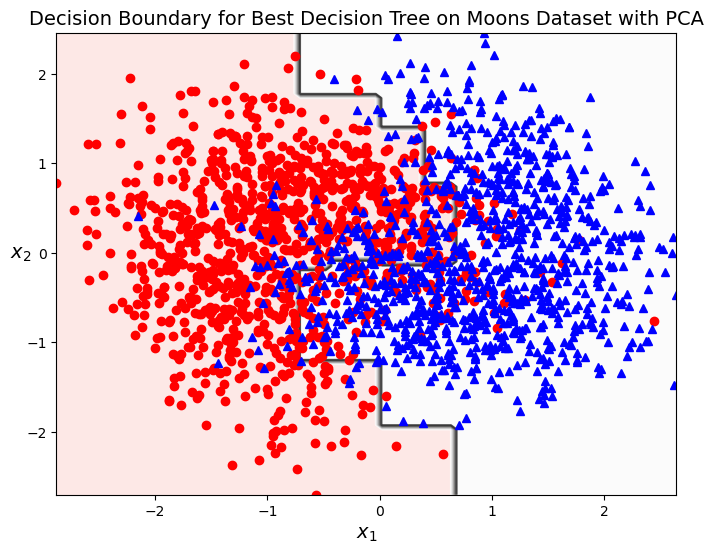

In [69]:
# Visualize the decision boundary
fig, ax = plt.subplots(figsize=(8, 6))
plot_decision_boundary(grid_search_cv.best_estimator_, X_test_prep, y_test,
                       axes=[np.min(X_test_prep[:,0]), np.max(X_test_prep[:,0]), np.min(X_test_prep[:,1]), np.max(X_test_prep[:,1])], cmap="Pastel1")
plt.title("Decision Boundary for Best Decision Tree on Moons Dataset with PCA")
plt.show()

This figure visualizes the decision boundary of the best-performing Decision Tree classifier (found via grid search) on the PCA-preprocessed Moons dataset. The data has been transformed using Principal Component Analysis (PCA) to align it with its principal components, reducing sensitivity to the original axis orientation. The plot shows the decision regions colored by predicted class (using the "Pastel1" colormap), with training data points overlaid as markers. The x-axis and y-axis represent the first and second principal components (PC1 and PC2), respectively. This preprocessing leads to a more stable and axis-aligned decision boundary compared to the original orientation, improving the model's generalization on rotated or axis-sensitive data. The title indicates this is the boundary for the optimized tree on the test set after PCA.

---
## 8.

_Exercise: Grow a forest._

a. Continuing the previous exercise, generate 1,000 subsets of the training set, each containing 100 instances selected randomly. Hint: you can use Scikit-Learn's `ShuffleSplit` class for this.

In [103]:
from sklearn.model_selection import ShuffleSplit

n_trees = 1000
n_instances = 100

mini_sets = []
print("Length of training set: ", len(X_train))

rs = ShuffleSplit(n_splits=n_trees, train_size=n_instances,
                  random_state=42) # yield random mini-batches of training data
print(f"Random mini-batches spliter: {rs}")

for mini_train_index, mini_test_index in rs.split(X_train):
    X_mini_train = X_train[mini_train_index]
    y_mini_train = y_train[mini_train_index]
    mini_sets.append((X_mini_train, y_mini_train))

print(f'Shape of mini_train_index: {mini_train_index.shape}')
print(f'Shape of mini_test_index: {mini_test_index.shape}')
print(f'Number of mini sets: {len(mini_sets)}')
mini_sets

Length of training set:  8000
Random mini-batches spliter: ShuffleSplit(n_splits=1000, random_state=42, test_size=None, train_size=100)
Shape of mini_train_index: (100,)
Shape of mini_test_index: (7900,)
Number of mini sets: 1000


[(array([[-3.15325488e-01,  4.94322659e-01],
         [ 1.07395888e+00, -3.83006874e-01],
         [ 1.23368080e+00, -2.02727544e-01],
         [ 1.45327595e+00, -4.97650493e-01],
         [ 6.29403125e-01, -4.58057181e-01],
         [ 1.31621613e+00, -4.96340629e-01],
         [ 6.61605020e-01, -5.25120656e-01],
         [ 1.17772151e+00,  2.12896730e-01],
         [ 1.27074026e+00,  8.37618484e-01],
         [ 2.40777741e-01, -4.05280317e-01],
         [ 2.09601211e+00,  2.29976411e-01],
         [ 3.96488095e-01, -3.07170096e-01],
         [-7.76673348e-01,  1.98996929e-01],
         [-8.88960092e-01,  1.06022488e+00],
         [ 1.21458297e+00, -3.55536724e-01],
         [ 1.72720880e+00,  3.94406303e-01],
         [ 1.96647532e+00,  2.91551342e-01],
         [-2.00602385e-01,  4.62530417e-02],
         [-1.19424550e+00,  1.64842526e-01],
         [-2.98171028e-01,  4.07082497e-01],
         [ 2.07327094e+00,  2.02547469e-02],
         [-7.43875589e-01,  1.01769167e+00],
         [

This code cell implements the first part of Exercise 8: "Grow a forest." It uses Scikit-Learn's `ShuffleSplit` class to generate 1,000 random subsets (mini-sets) from the training data (`X_train`, `y_train`), each containing 100 instances selected randomly. This is a key step in building a random forest, as each subset will be used to train an individual decision tree, promoting diversity and reducing overfitting.

- **`ShuffleSplit`**: Configured with `n_splits=1000` (number of subsets), `train_size=100` (size of each subset), and `random_state=42` for reproducibility. It yields indices for mini-training sets without replacement, simulating bootstrapping.
- **Loop**: For each split, it extracts the corresponding features (`X_mini_train`) and labels (`y_mini_train`) from the full training set and appends them as tuples to `mini_sets`.
- **Output**: Prints the length of the original training set, details of the splitter, shapes of the last mini-batch indices (for verification), and the total number of mini-sets created. The final `mini_sets` list contains 1,000 tuples, each ready for training a decision tree.

This approach ensures each tree is trained on a slightly different subset, mimicking the randomness in random forests to improve generalization. In the next steps, you'll train decision trees on these mini-sets and aggregate their predictions via majority voting.

b. Train one Decision Tree on each subset, using the best hyperparameter values found above. Evaluate these 1,000 Decision Trees on the test set. Since they were trained on smaller sets, these Decision Trees will likely perform worse than the first Decision Tree, achieving only about 80% accuracy.

In [104]:
from sklearn.base import clone

forest = [clone(grid_search_cv.best_estimator_) for _ in range(n_trees)]
print(f'Number of trees in the forest: {len(forest)}')

accuracy_scores = []

for tree, (X_mini_train, y_mini_train) in zip(forest, mini_sets):
    tree.fit(X_mini_train, y_mini_train)

    y_pred = tree.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

np.mean(accuracy_scores)

Number of trees in the forest: 1000


0.8046449999999999

This code cell implements part (b) of Exercise 8: "Grow a forest." It trains 1,000 individual Decision Tree classifiers, each on a random mini-subset of 100 instances from the training data (`X_train`, `y_train`), using the best hyperparameters found via grid search (`grid_search_cv.best_estimator_`). This simulates the bootstrapping process in Random Forests to introduce diversity and reduce overfitting.

- **`clone(grid_search_cv.best_estimator_)`**: Creates 1,000 identical copies of the optimized Decision Tree model to ensure each tree starts with the same hyperparameters but is trained on different subsets.
- **Training Loop**: For each tree and corresponding mini-set (generated in the previous cell), the tree is fitted on the mini-training data and then used to predict on the full test set (`X_test`). The accuracy score for each tree's predictions is stored in `accuracy_scores`.
- **Output**: Prints the number of trees (1,000) and computes the mean accuracy across all trees using `np.mean(accuracy_scores)`. As expected, individual trees trained on smaller subsets perform worse than the full-trained model (around 80% accuracy), highlighting the need for ensemble aggregation like majority voting in Random Forests to improve overall performance. The final mean accuracy is displayed, demonstrating the variance in individual tree performance.

Then, more statistics about these 1,000 Decision Trees:

In [105]:
accuracy_scores_array = np.array(accuracy_scores)
print("Mean accuracy:", accuracy_scores_array.mean())
print("Standard deviation:", accuracy_scores_array.std())
print("Minimum accuracy:", accuracy_scores_array.min())
print("Maximum accuracy:", accuracy_scores_array.max())


Mean accuracy: 0.8046449999999999
Standard deviation: 0.0267866846586135
Minimum accuracy: 0.702
Maximum accuracy: 0.862


c. Now comes the magic. For each test set instance, generate the predictions of the 1,000 Decision Trees, and keep only the most frequent prediction (you can use SciPy's `mode()` function for this). This gives you _majority-vote predictions_ over the test set.

In [106]:
Y_pred = np.empty([n_trees, len(X_test)], dtype=np.uint8)

for tree_index, tree in enumerate(forest):
    Y_pred[tree_index] = tree.predict(X_test)

print(f'Y_pred contains {Y_pred.shape[-1]} predictions for each of the {n_trees} trees and has shape: {Y_pred.shape}')

Y_pred contains 2000 predictions for each of the 1000 trees and has shape: (1000, 2000)


In [107]:
from scipy.stats import mode

y_pred_majority_votes, n_votes = mode(Y_pred, axis=0) # majority vote across all trees

It aggregates predictions from the 1,000 individual decision trees trained on random mini-subsets of the training data.

- **`from scipy.stats import mode`**: Imports the `mode` function from SciPy, which computes the most frequent value (mode) along an axis of an array.
- **`y_pred_majority_votes, n_votes = mode(Y_pred, axis=0)`**: Applies majority voting across the predictions of all trees for each test instance. 
    - `Y_pred` is a 2D array (shape: 1000 trees × number of test instances) containing binary predictions (0 or 1). 
    - `axis=0` computes the mode along the tree axis.
    - resulting in `y_pred_majority_votes` (the majority class for each test instance) and `n_votes` (the count of votes for the majority class). 

This ensemble approach reduces variance and improves accuracy compared to individual trees, mimicking Random Forest behavior. The majority vote predictions can now be evaluated against `y_test` for overall forest performance.

d. Evaluate these predictions on the test set: you should obtain a slightly higher accuracy than your first model (about 0.5 to 1.5% higher). Congratulations, you have trained a Random Forest classifier!

In [108]:
accuracy_score(y_test, y_pred_majority_votes.reshape([-1]))

0.873